# Agent3 - 정량 분석 탐색 노트북

`agents/agent3_quant.py`(제품 코드)를 불러와서 결과를 확인하고 시각화하는 탐색용 노트북입니다.
이 노트북은 프로젝트 루트(`diplomacy_agent/`)에서 열어야 import가 정상 동작합니다.


In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))  # 프로젝트 루트를 path에 추가

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['axes.unicode_minus'] = False

from data.dummy_data import generate_countries, OPPORTUNITY_FIELDS
from agents.agent3_quant import Agent3Analyzer

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)


## 1. 데이터 로드 & Agent3 실행

In [2]:
raw = generate_countries()
agent3 = Agent3Analyzer(raw)
out = agent3.run_all()
list(out.keys())


['risk_score',
 'cooperation_index',
 'opportunity_score',
 'opportunity_ranking',
 'feature_matrix',
 'similarity_matrix',
 'cluster',
 'pca_coords']

## 2. 위험도 점수

In [3]:
risk = out['risk_score'].sort_values(ascending=False)
risk


country
캄보디아      73.47
가나        71.20
몽골        59.39
케냐        59.03
필리핀       56.69
베트남       48.87
미얀마       48.61
방글라데시     46.79
탄자니아      44.86
인도네시아     41.81
라오스       41.69
우즈베키스탄    40.89
네팔        38.15
볼리비아      29.68
에티오피아     12.51
Name: risk_score, dtype: float64

/tmp/ipykernel_571/907786824.py:6: UserWarning: Glyph 52868 (\N{HANGUL SYLLABLE KAM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_571/907786824.py:6: UserWarning: Glyph 48372 (\N{HANGUL SYLLABLE BO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_571/907786824.py:6: UserWarning: Glyph 46356 (\N{HANGUL SYLLABLE DI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_571/907786824.py:6: UserWarning: Glyph 50500 (\N{HANGUL SYLLABLE A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_571/907786824.py:6: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_571/907786824.py:6: UserWarning: Glyph 45208 (\N{HANGUL SYLLABLE NA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_571/907786824.py:6: UserWarning: Glyph 47805 (\N{HANGUL SYLLABLE MONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_571

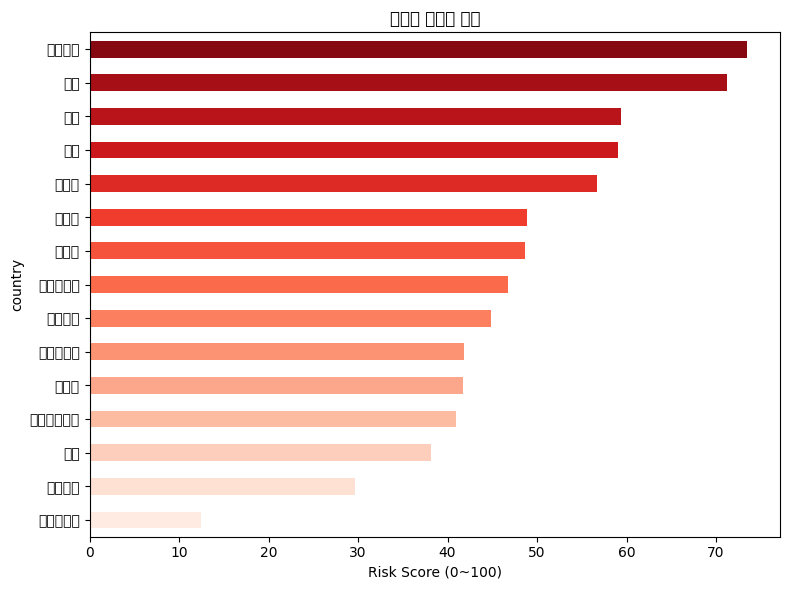

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))
risk.plot(kind='barh', ax=ax, color=sns.color_palette('Reds_r', len(risk)))
ax.set_xlabel('Risk Score (0~100)')
ax.set_title('국가별 위험도 점수')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


## 3. Cooperation Index (5단계)

In [5]:
coop = out['cooperation_index'].sort_values('score', ascending=False)
coop


,score,grade
country,,
네팔,84.29,5
방글라데시,71.81,5
볼리비아,57.71,5
미얀마,56.01,4
가나,55.65,4
탄자니아,55.38,4
필리핀,52.13,3
라오스,51.80,3
캄보디아,51.11,3


/tmp/ipykernel_571/3584599631.py:8: UserWarning: Glyph 45348 (\N{HANGUL SYLLABLE NE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_571/3584599631.py:8: UserWarning: Glyph 54036 (\N{HANGUL SYLLABLE PAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_571/3584599631.py:8: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_571/3584599631.py:8: UserWarning: Glyph 44544 (\N{HANGUL SYLLABLE GEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_571/3584599631.py:8: UserWarning: Glyph 46972 (\N{HANGUL SYLLABLE RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_571/3584599631.py:8: UserWarning: Glyph 45936 (\N{HANGUL SYLLABLE DE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_571/3584599631.py:8: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipy

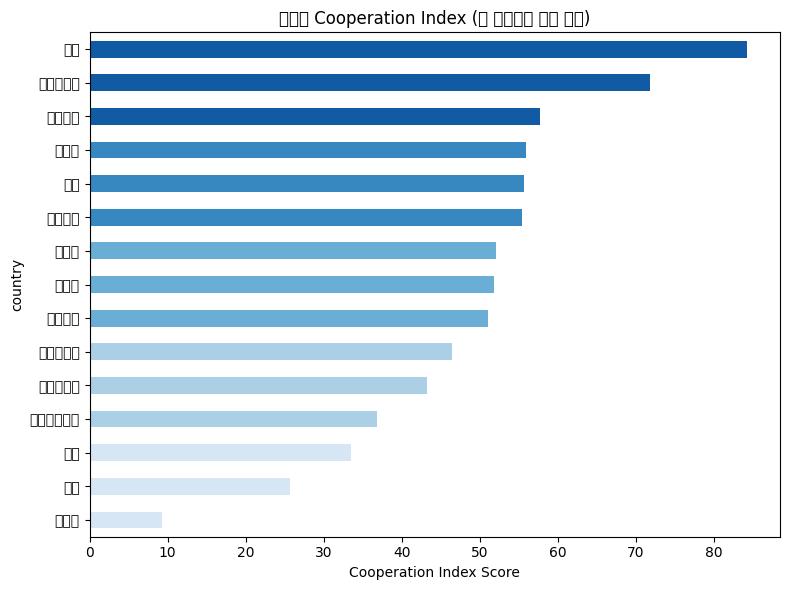

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = sns.color_palette('Blues', 5)
bar_colors = [colors[g-1] for g in coop['grade']]
coop['score'].plot(kind='barh', ax=ax, color=bar_colors)
ax.set_xlabel('Cooperation Index Score')
ax.set_title('국가별 Cooperation Index (색 진할수록 등급 높음)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


## 4. Cooperation Opportunity Score - 분야별 히트맵

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 54044 (\N{HANGUL SYLLABLE PAM}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 47308 (\N{HANGUL SYLLABLE RYO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/l

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48288 (\N{HANGUL SYLLABLE BE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45224 (\N{HANGUL SYLLABLE NAM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/loc

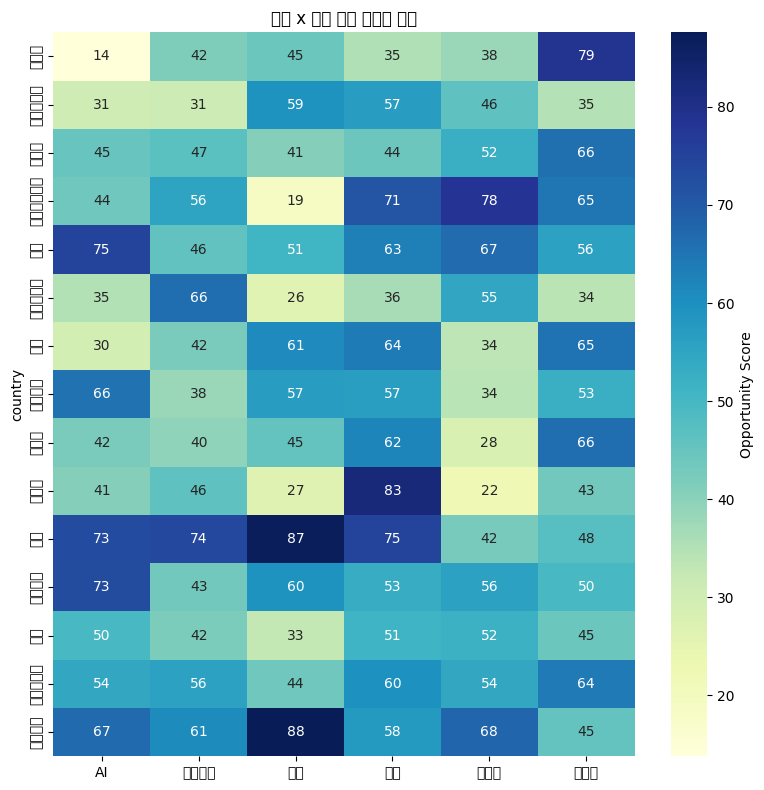

In [7]:
opp = out['opportunity_score']
fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(opp, annot=True, fmt='.0f', cmap='YlGnBu', ax=ax, cbar_kws={'label': 'Opportunity Score'})
ax.set_title('국가 x 분야 협력 가능성 점수')
plt.tight_layout()
plt.show()


In [8]:
top_field_per_country = opp.idxmax(axis=1)
top_field_per_country.value_counts()


에너지     5
의료      3
AI      3
인프라     2
스마트팜    1
문화      1
Name: count, dtype: int64

## 5. KMeans 군집 결과 (PCA 2D 산점도)

/tmp/ipykernel_571/2908773254.py:10: UserWarning: Glyph 44397 (\N{HANGUL SYLLABLE GUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_571/2908773254.py:10: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_571/2908773254.py:10: UserWarning: Glyph 44400 (\N{HANGUL SYLLABLE GUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_571/2908773254.py:10: UserWarning: Glyph 51665 (\N{HANGUL SYLLABLE JIB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_571/2908773254.py:10: UserWarning: Glyph 53804 (\N{HANGUL SYLLABLE TU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_571/2908773254.py:10: UserWarning: Glyph 50689 (\N{HANGUL SYLLABLE YEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_571/2908773254.py:10: UserWarning: Glyph 49353 (\N{HANGUL SYLLABLE SAEG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(

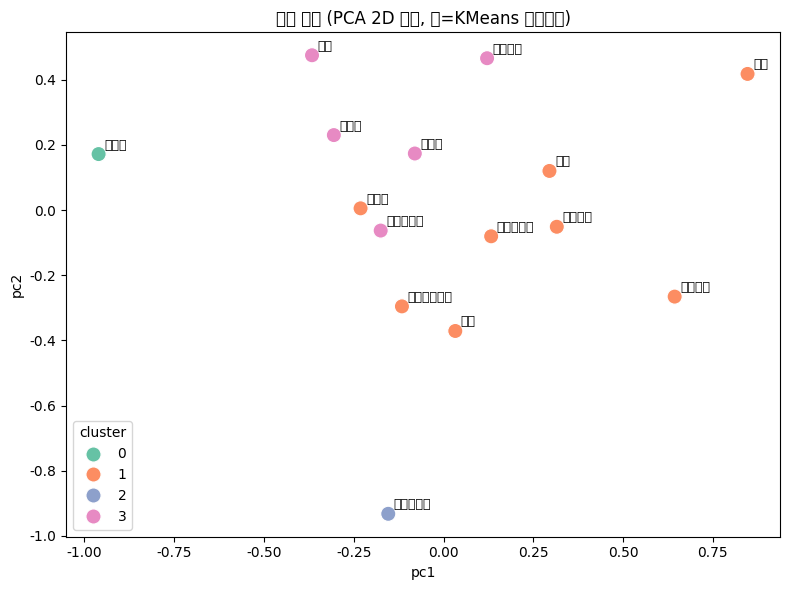

In [9]:
plot_df = out['pca_coords'].copy()
plot_df['cluster'] = out['cluster']
plot_df['risk'] = out['risk_score']

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=plot_df, x='pc1', y='pc2', hue='cluster', palette='Set2', s=120, ax=ax)
for country, row in plot_df.iterrows():
    ax.annotate(country, (row['pc1'], row['pc2']), fontsize=9, xytext=(4, 4), textcoords='offset points')
ax.set_title('국가 군집 (PCA 2D 투영, 색=KMeans 클러스터)')
plt.tight_layout()
plt.show()


## 6. 유사국가 추천

In [10]:
target = '베트남'  # 원하는 국가로 바꿔서 실행
sims = agent3.recommend_similar(out['similarity_matrix'], target, top_n=5)
sims


country
몽골        0.825066
필리핀       0.798747
라오스       0.714230
방글라데시     0.658503
우즈베키스탄    0.635381
Name: 베트남, dtype: float64

/tmp/ipykernel_571/2715156171.py:6: UserWarning: Glyph 53076 (\N{HANGUL SYLLABLE KO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_571/2715156171.py:6: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_571/2715156171.py:6: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_571/2715156171.py:6: UserWarning: Glyph 50976 (\N{HANGUL SYLLABLE YU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_571/2715156171.py:6: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_571/2715156171.py:6: UserWarning: Glyph 47805 (\N{HANGUL SYLLABLE MONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_571/2715156171.py:6: UserWarning: Glyph 44264 (\N{HANGUL SYLLABLE GOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipyke

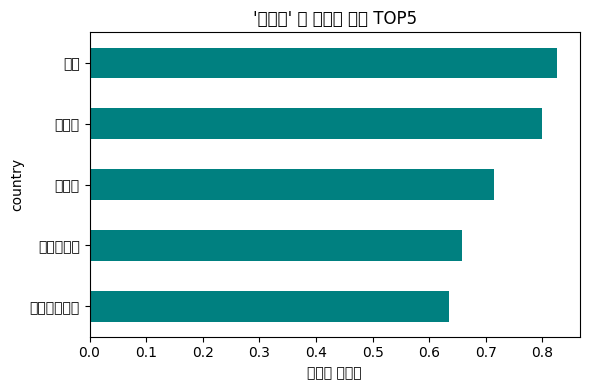

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
sims.plot(kind='barh', ax=ax, color='teal')
ax.set_xlabel('코사인 유사도')
ax.set_title(f"'{target}' 와 유사한 국가 TOP{len(sims)}")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


## 7. 전체 유사도 히트맵 (모든 국가 쌍)

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 48288 (\N{HANGUL SYLLABLE BE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 45224 (\N{HANGUL SYLLABLE NAM}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 45348 (\N{HANGUL SYLLABLE NE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/loc

/tmp/ipykernel_571/4237920956.py:4: UserWarning: Glyph 44397 (\N{HANGUL SYLLABLE GUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_571/4237920956.py:4: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_571/4237920956.py:4: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_571/4237920956.py:4: UserWarning: Glyph 53076 (\N{HANGUL SYLLABLE KO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_571/4237920956.py:4: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_571/4237920956.py:4: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_571/4237920956.py:4: UserWarning: Glyph 50976 (\N{HANGUL SYLLABLE YU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipyker

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44397 (\N{HANGUL SYLLABLE GUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 53076 (\N{HANGUL SYLLABLE KO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50976 (\N{HANGUL SYLLABLE YU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/loc

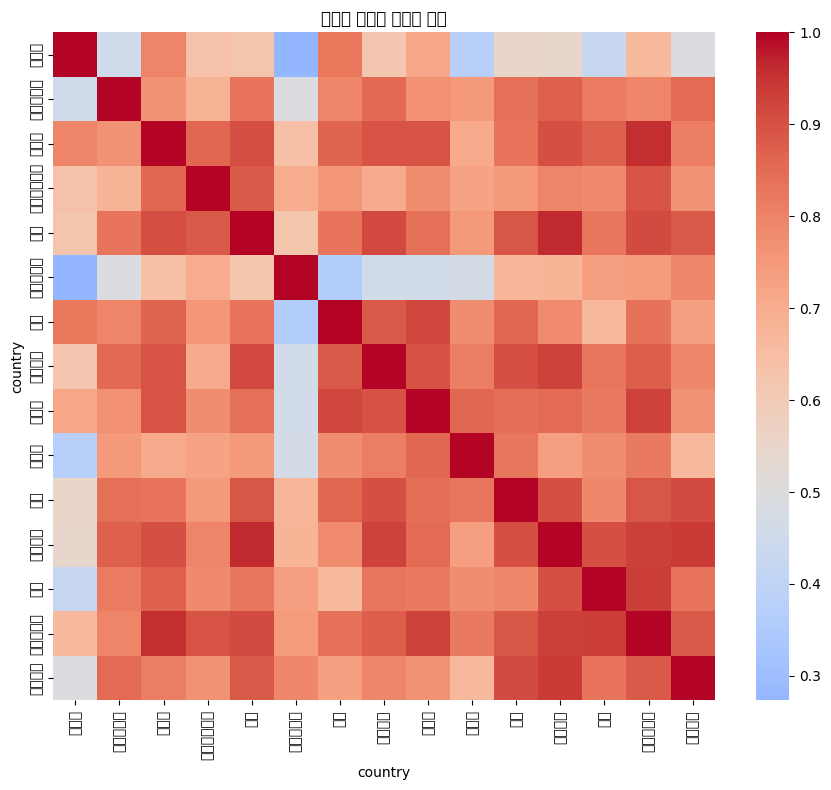

In [12]:
fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(out['similarity_matrix'], cmap='coolwarm', center=0.5, annot=False, ax=ax)
ax.set_title('국가간 코사인 유사도 행렬')
plt.tight_layout()
plt.show()
